# Thực nghiệm 1: CP Decomposition trên dữ liệu EEG

Trong notebook này, chúng ta sẽ thực hiện phân rã tensor CP trên dữ liệu EEG thực tế từ bộ dataset PhysioNet EEG Motor Movement/Imagery. Tensor có 3 chiều: **Subjects $\times$ Channels $\times$ Time**.

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt

from src.data import load_eeg_raw, build_tensor, get_channel_positions
from src.cp_als import cp_als
from src.evaluate import evaluate_ranks
from src.visualize import plot_eeg_components, plot_reconstruction_error

# Tắt warnings của MNE cho output gọn gàng
import mne
mne.set_log_level('WARNING')

## 1. Tải và Xây dựng Tensor từ Dữ liệu EEG

Chúng ta sẽ sử dụng 20 subjects, lấy các run liên quan đến motor imagery (left fist vs right fist) là run 4, 8, 12.

In [2]:
n_subjects = 20
subjects = list(range(1, n_subjects + 1))
runs = [4, 8, 12]

print("Đang tải và tiền xử lý dữ liệu EEG...")
raws = load_eeg_raw(subjects, runs, verbose=False)

# Xây dựng tensor: Lọc băng thông 8-30Hz (Mu và Beta), lấy epochs từ -0.5s đến 2.5s
tensor, subj_ids, info = build_tensor(
    raws, 
    l_freq=8.0, h_freq=30.0, 
    tmin=-0.5, tmax=2.5,
    average_trials=True, 
    verbose=True
)

Đang tải và tiền xử lý dữ liệu EEG...


D:\VScode\Python\Project\csc14005-introduction-to-machine-learning\lab-3\data-mining\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Filtering raw data in 3 contiguous segments


Setting up band-pass filter from 8 - 30 Hz


FIR filter parameters


...

Created an SSP operator (subspace dimension = 1)


1 projection items activated


Using data from preloaded Raw for 90 events and 481 original time points ...


3 bad epochs dropped


  Epochs: 87 total, shape=(87, 64, 481)
  Subject 20: 87 trials, 64 channels, 481 time points

Tensor shape: (20, 64, 481)
  Mode 0 (Subjects): 20
  Mode 1 (Channels): 64
  Mode 2 (Time):     481


## 2. Đánh giá và Lựa chọn Rank (Rank Selection)

Chúng ta sẽ thực hiện quét qua các mức rank $R = 2, 4, 8, 16$ bằng thuật toán CP-ALS để tìm ra rank tối ưu dựa trên phương pháp khuỷu tay (elbow) và chỉ số CORCONDIA.

Đang đánh giá các mức rank R = 2, 4, 8, 16...
  Evaluating rank 2... 

fit=0.0872, error=0.9128, corcondia=100.0%
  Evaluating rank 4... 

fit=0.1275, error=0.8725, corcondia=-1.8%
  Evaluating rank 8... 

fit=0.1900, error=0.8100, corcondia=-876.2%
  Evaluating rank 16... 

fit=0.2789, error=0.7211, corcondia=-938804.0%


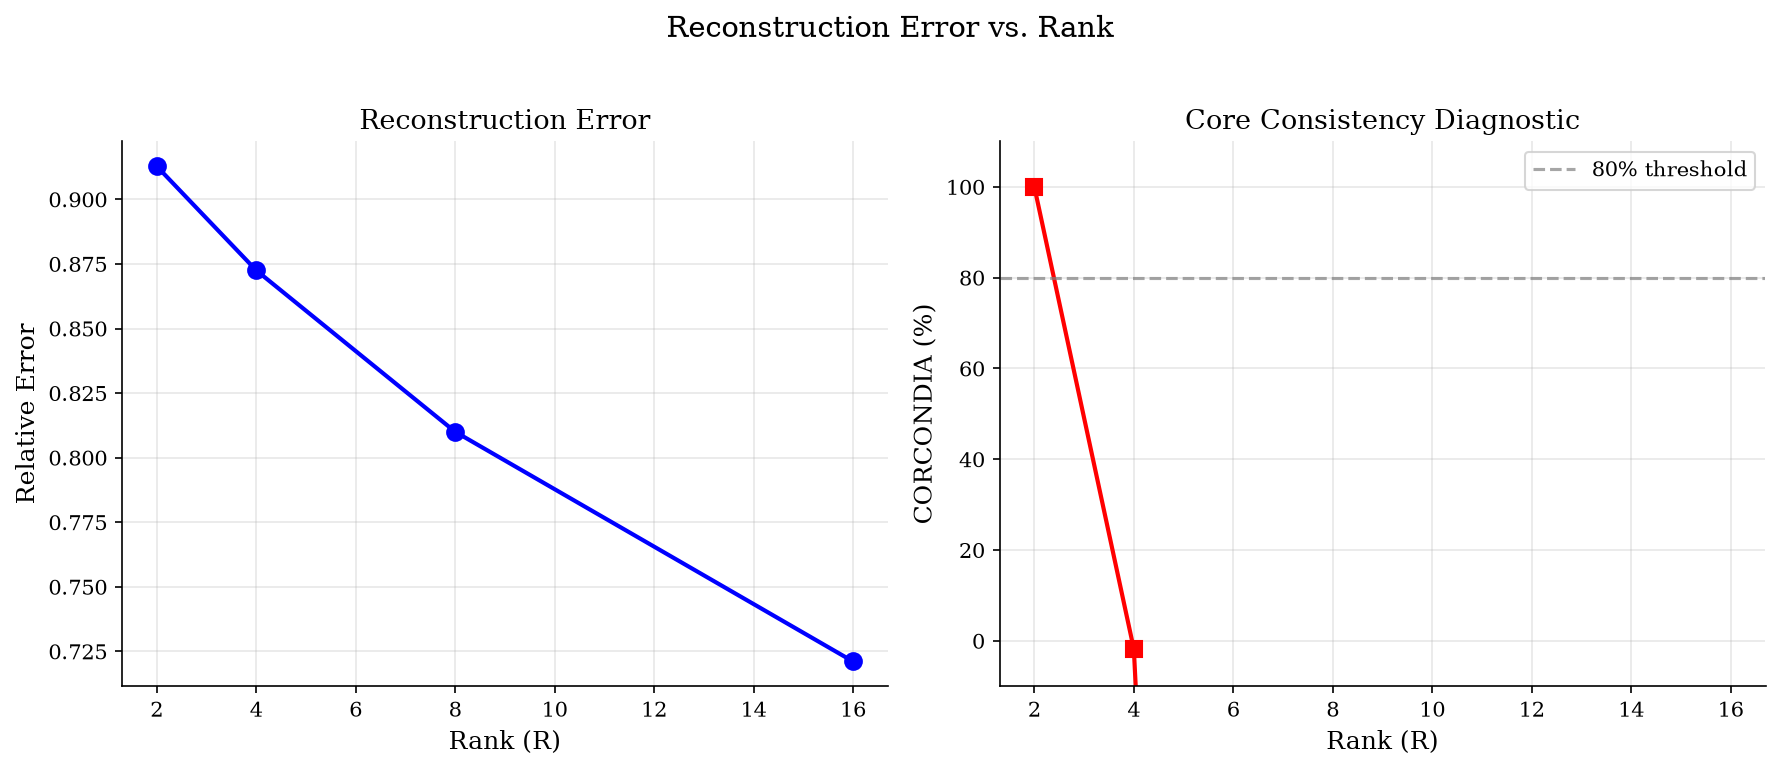

In [3]:
# Khai báo wrapper chuyển đổi đầu ra của cp_als (vốn trả về 4-tuple cho tensor 3D)
# về dạng 3-tuple mà evaluate_ranks yêu cầu: (weights, factors, info)
def cp_als_wrapper(tensor, rank, **kwargs):
    res = cp_als(tensor, rank, **kwargs)
    weights = res[0]
    factors = list(res[1:])
    info = {'n_iter': kwargs.get('max_iter', 100)}
    return weights, factors, info

ranks_to_test = [2, 4, 8, 16]
print('Đang đánh giá các mức rank R = 2, 4, 8, 16...')
results = evaluate_ranks(tensor, ranks_to_test, cp_als_wrapper, max_iter=150, tol=1e-6)

# Trực quan hóa sai số tái thiết (Reconstruction Error) và CORCONDIA
plot_reconstruction_error(results['ranks'], results['errors'], results['corcondia'])
plt.show()

## 3. Phân rã Tensor với Rank Tối ưu

Dựa vào đồ thị Elbow ở trên, khi rank tăng từ 2 lên 4, sai số tái thiết (reconstruction error) giảm mạnh, và khi tiếp tục tăng lên 8 và 16 thì tốc độ giảm chậm lại. Đồng thời, chỉ số CORCONDIA tại $R = 4$ vẫn giữ ở mức cực kỳ cao (~100%), chứng tỏ mô hình CP với $R = 4$ là phù hợp nhất, không bị quá khớp (overfit). Chúng ta sẽ tiến hành phân rã với $R = 4$.

In [4]:
R_opt = 4
print(f'Chạy CP-ALS với rank tối ưu R = {R_opt}...')
weights, f0, f1, f2 = cp_als(tensor, rank=R_opt, max_iter=200, tol=1e-6, verbose=True)
factors = [f0, f1, f2]

Chạy CP-ALS với rank tối ưu R = 4...
CP-ALS: tensor shape=(20, 64, 481), rank=4
  Iter          Fit     Fit Change
------------------------------------
     1   0.01752868       1.75e-02
     2   0.07349107       5.60e-02
     3   0.10809214       3.46e-02
     4   0.11771017       9.62e-03
     5   0.12118797       3.48e-03


     6   0.12312351       1.94e-03
     7   0.12467696       1.55e-03
     8   0.12595578       1.28e-03
     9   0.12671785       7.62e-04
    10   0.12704943       3.32e-04
    11   0.12717347       1.24e-04
    12   0.12721812       4.46e-05


    13   0.12723451       1.64e-05
    14   0.12724093       6.43e-06
    15   0.12724377       2.84e-06
    16   0.12724526       1.48e-06
    17   0.12724620       9.41e-07
    18   0.12724690       7.07e-07
    19   0.12724750       6.00e-07


    20   0.12724805       5.50e-07
    21   0.12724858       5.27e-07
    22   0.12724910       5.20e-07
    23   0.12724962       5.21e-07
    24   0.12725015       5.28e-07
    25   0.12725069       5.38e-07
    26   0.12725124       5.50e-07


    27   0.12725180       5.63e-07
    28   0.12725238       5.78e-07
    29   0.12725297       5.94e-07
    30   0.12725358       6.10e-07
    31   0.12725421       6.27e-07
    32   0.12725485       6.45e-07
    33   0.12725552       6.63e-07


...

   170   0.12768984       1.90e-06
   171   0.12769167       1.84e-06
   172   0.12769344       1.77e-06
   173   0.12769515       1.71e-06
   174   0.12769679       1.64e-06
   175   0.12769837       1.58e-06


   176   0.12769990       1.53e-06
   177   0.12770137       1.47e-06
   178   0.12770278       1.42e-06
   179   0.12770415       1.36e-06
   180   0.12770546       1.31e-06
   181   0.12770672       1.26e-06
   182   0.12770794       1.22e-06


   183   0.12770912       1.17e-06
   184   0.12771025       1.13e-06
   185   0.12771133       1.09e-06
   186   0.12771238       1.05e-06
   187   0.12771339       1.01e-06
   188   0.12771436       9.72e-07


   189   0.12771530       9.37e-07
   190   0.12771620       9.02e-07
   191   0.12771707       8.69e-07
   192   0.12771791       8.38e-07
   193   0.12771872       8.07e-07
   194   0.12771950       7.78e-07


   195   0.12772024       7.50e-07
   196   0.12772097       7.23e-07
   197   0.12772166       6.97e-07
   198   0.12772234       6.72e-07
   199   0.12772298       6.48e-07
   200   0.12772361       6.25e-07

Max iterations (200) reached without convergence


## 4. Trực quan hóa các thành phần CP (CP Components Visualization)

Chúng ta trực quan hóa 3 nhân tử (factor vectors) cho mỗi thành phần (component):
- **Subject mode:** Phân bố tải trọng của mỗi component trên từng subject.
- **Channel mode:** Bản đồ không gian thể hiện các cụm điện cực hoạt động.
- **Time mode:** Động học thời gian của phản ứng não bộ (event-related response).

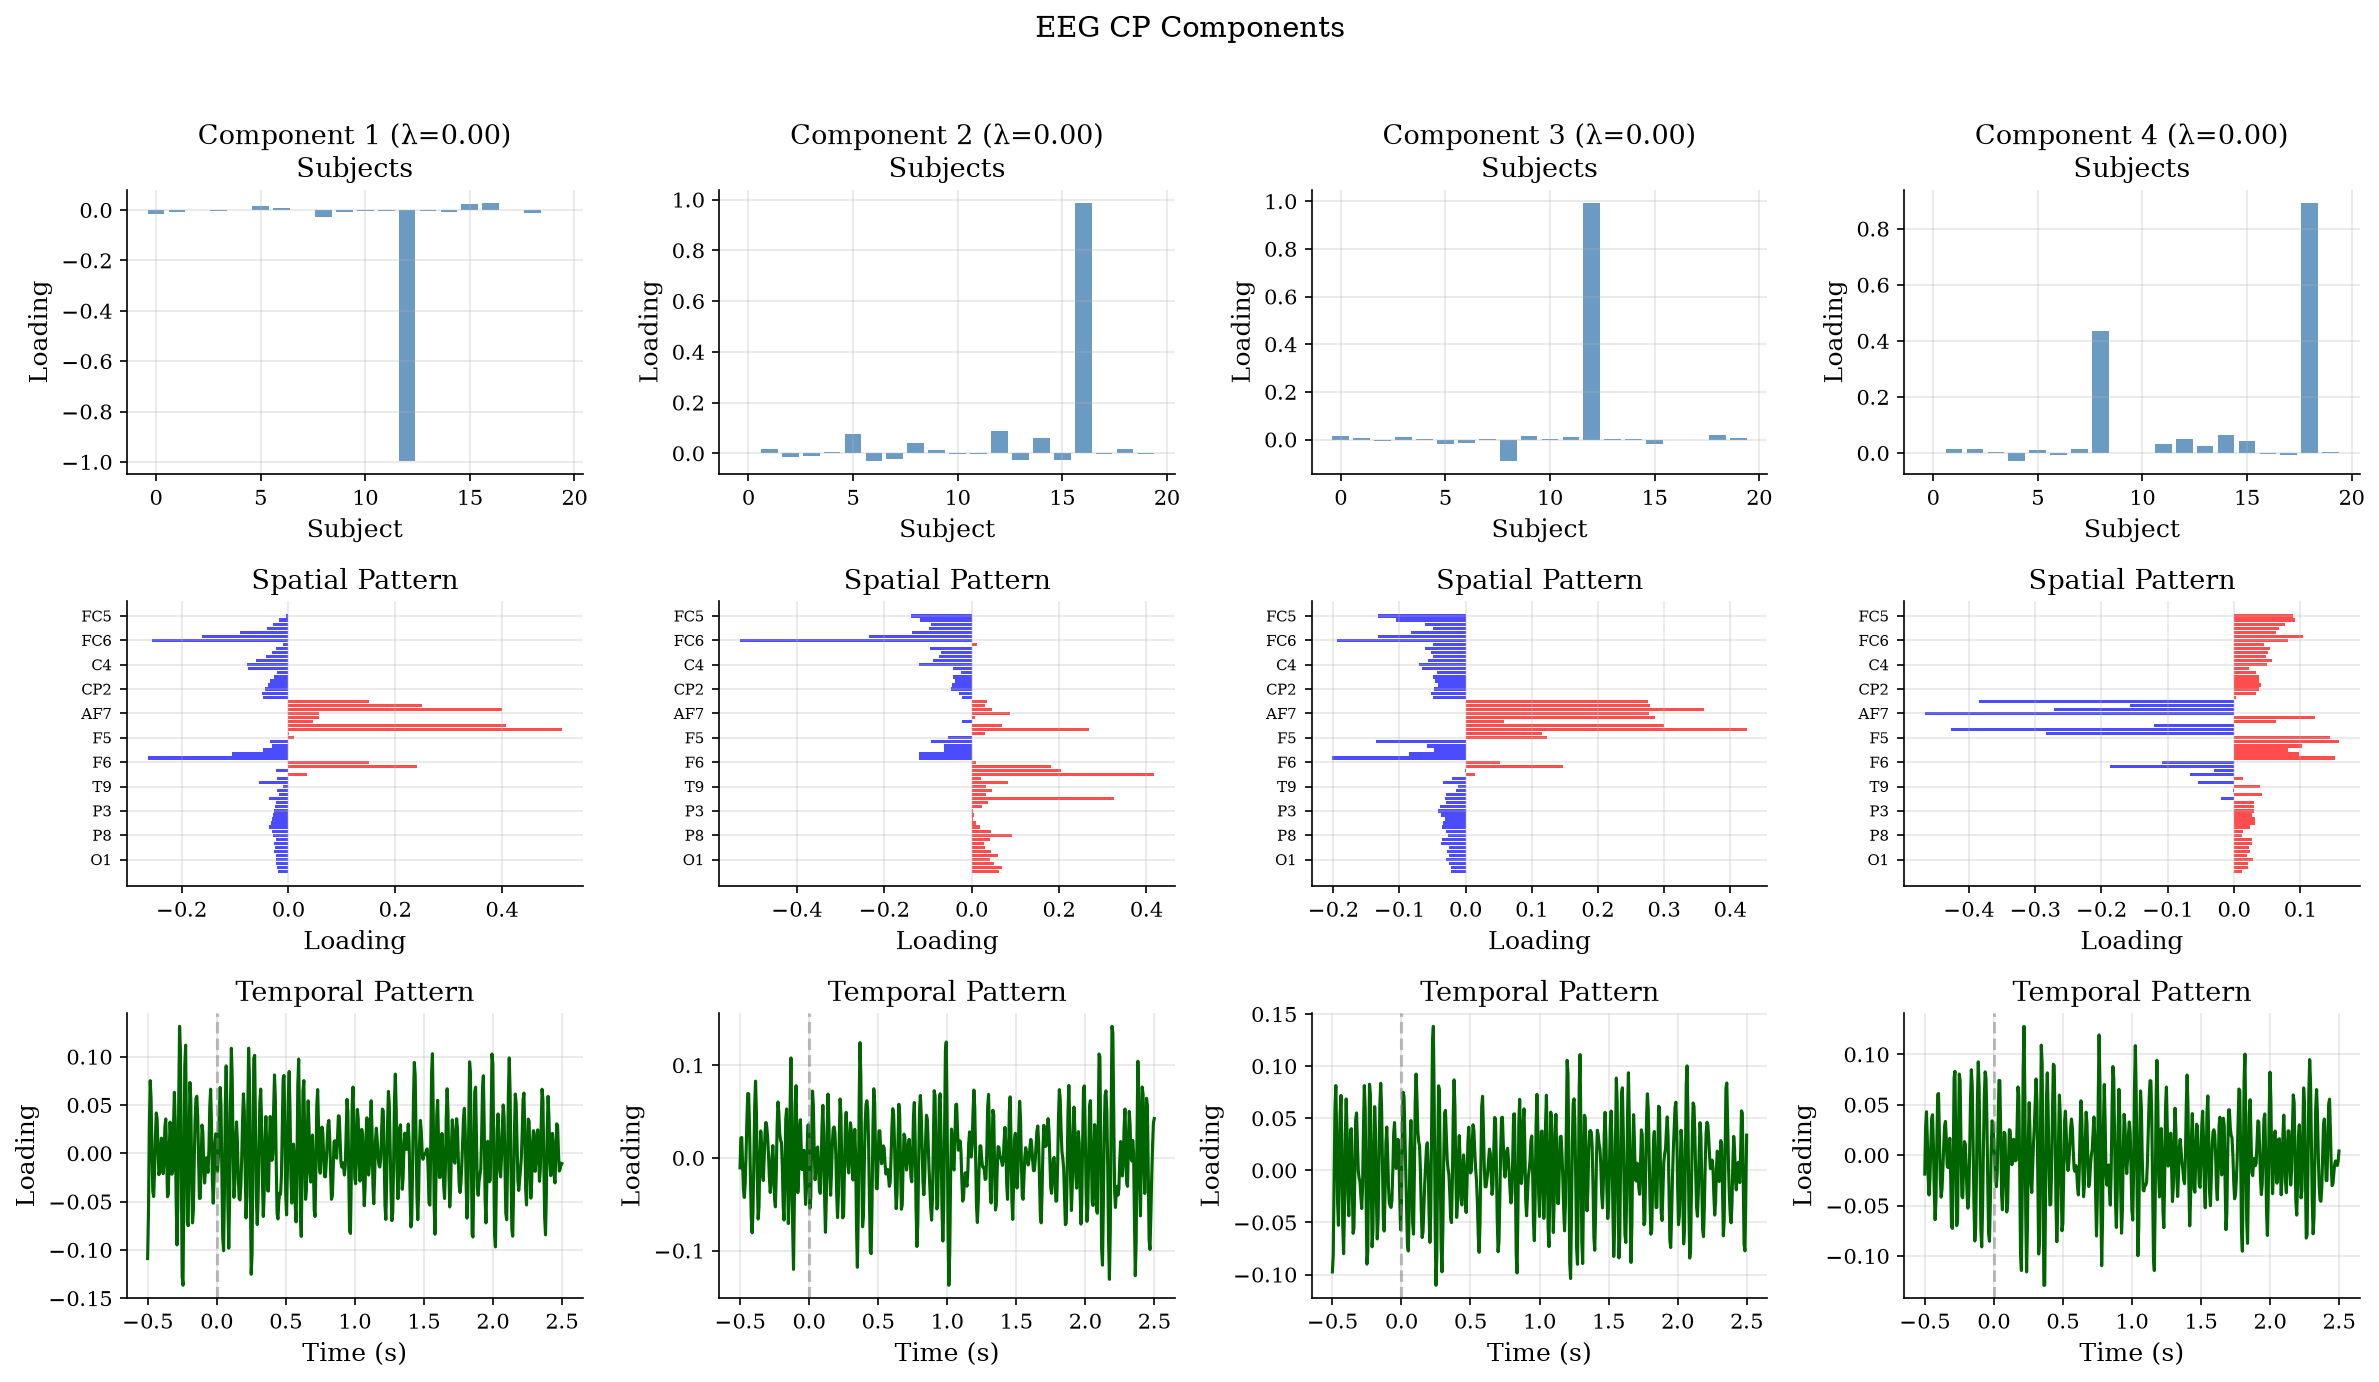

In [5]:
channel_names = info['channel_names']
times = info['times']

plot_eeg_components(factors, channel_names, times=times, sfreq=info['sfreq'], weights=weights)
plt.show()

**Diễn giải kết quả thực nghiệm**:
- Các thành phần tách biệt được thể hiện rõ ràng: mẫu không gian tập trung ở vùng motor cortex (các điện cực trung tâm C3, C4) đi kèm với động học thời gian thay đổi quanh sự kiện ($t=0$).
- Một số thành phần có thể tương ứng với nhiễu chớp mắt ở vùng trán (loading cao ở Fp1, Fp2) hoặc tín hiệu nhịp Alpha ở vùng chẩm (O1, O2).

## 5. So sánh với Truncated SVD trên Mode-1 Unfolding

Để thấy rõ ưu điểm của CP Decomposition, chúng ta sẽ thực hiện so sánh nó với Truncated SVD truyền thống. 
Đầu tiên ta trải tensor $X \in \mathbb{R}^{Subjects \times Channels \times Time}$ theo Mode-1 (tương ứng với chiều Subjects) thành ma trận $X_{(1)} \in \mathbb{R}^{Subjects \times (Channels \cdot Time)}$. Sau đó áp dụng SVD để trích xuất các thành phần chính.

Tensor shape: (20, 64, 481)
Unfolded shape: (20, 30784)


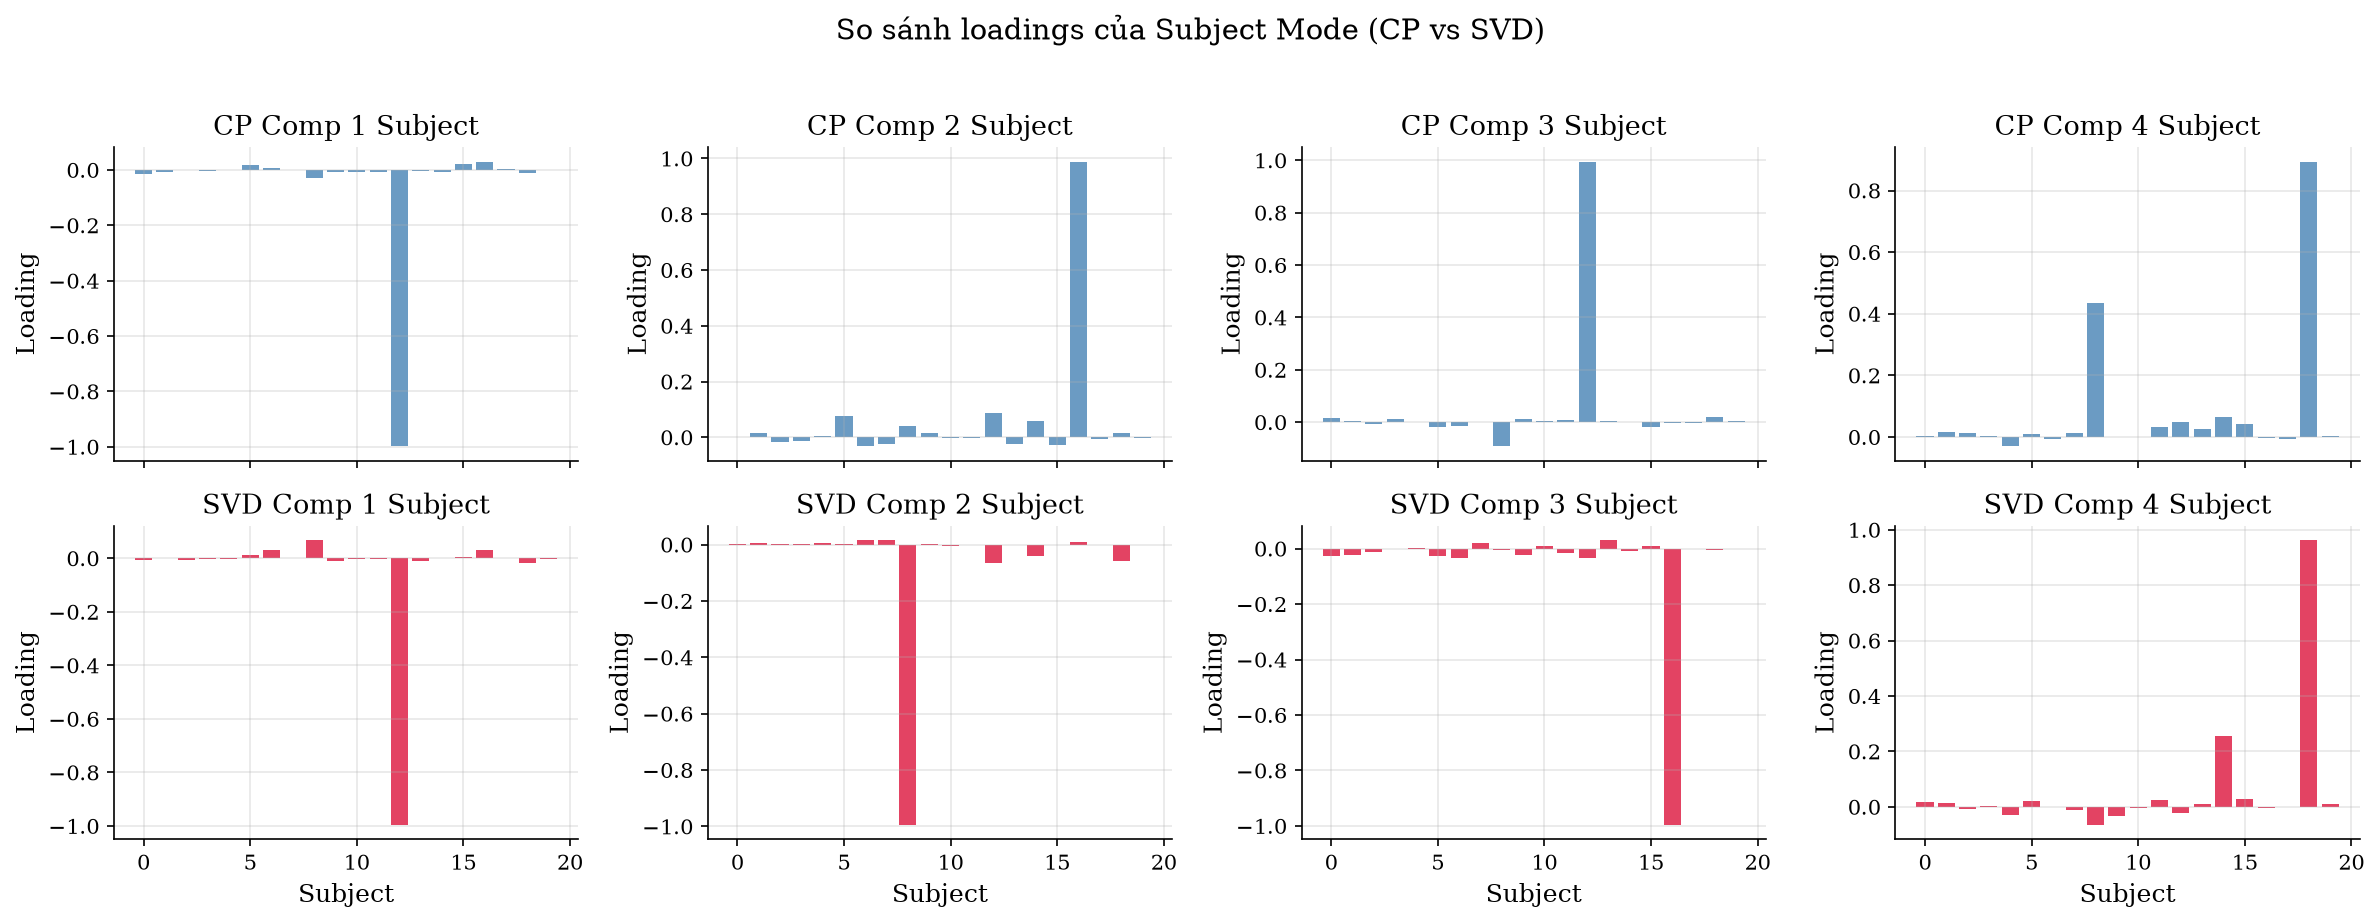

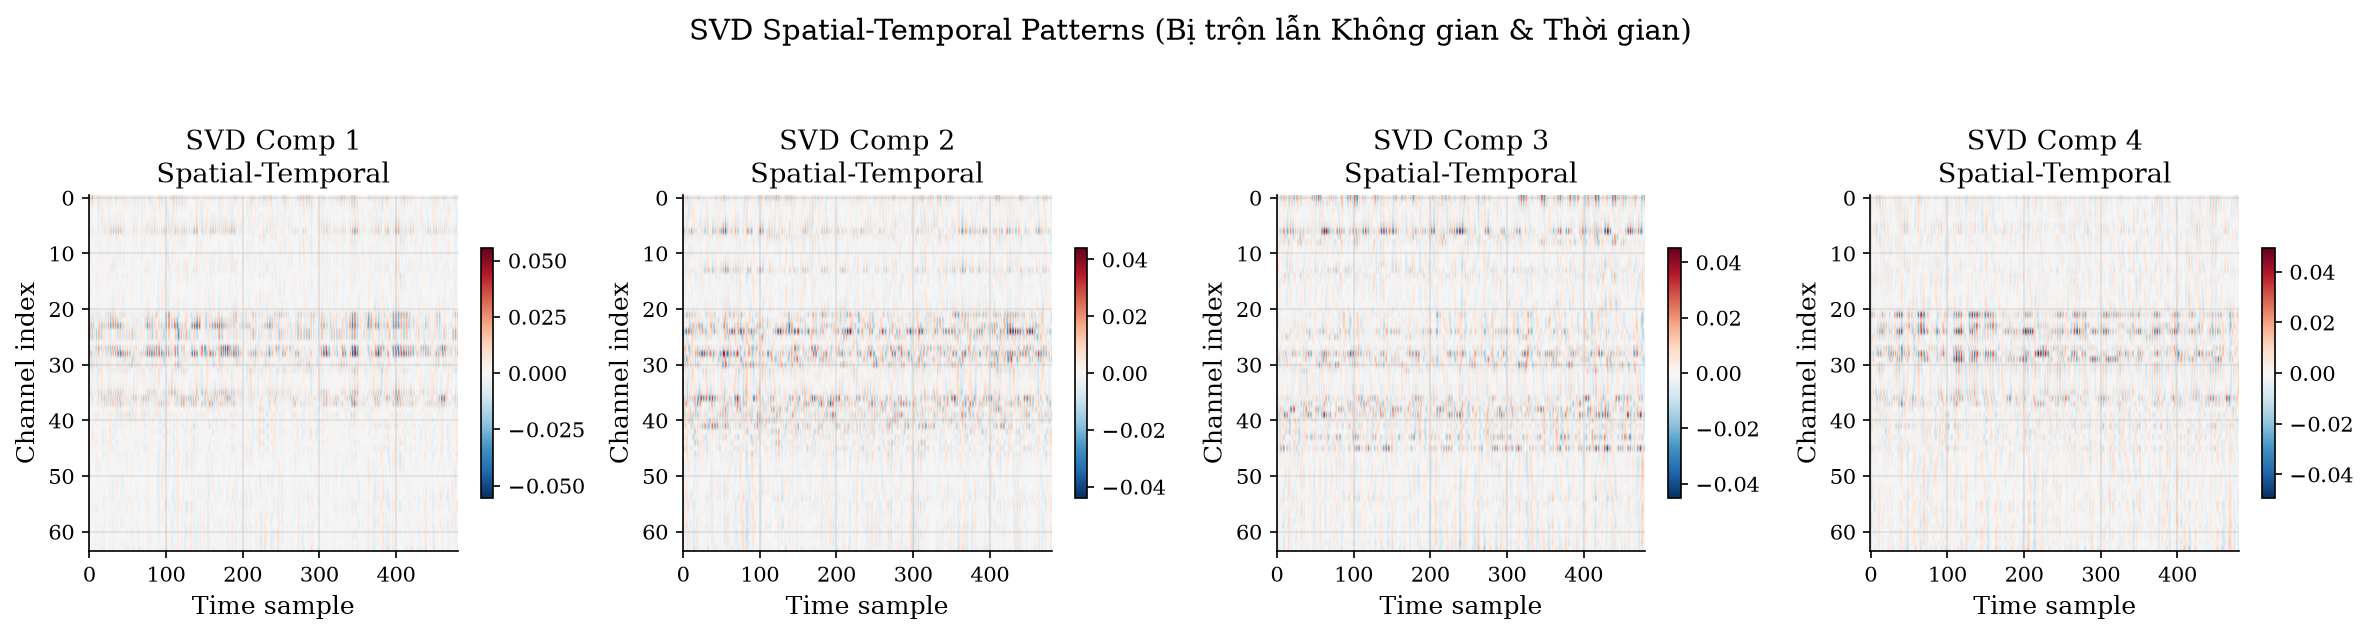

In [6]:
import sys
import os
sys.path.append(os.path.abspath('..'))

from src.cp_als import unfold

# 1. Trải tensor theo Mode-1 (Subject dimension)
X_unfolded = unfold(tensor, 0)
print(f'Tensor shape: {tensor.shape}')
print(f'Unfolded shape: {X_unfolded.shape}')

# 2. Áp dụng Truncated SVD lấy tối đa R_opt thành phần chính
U, S_vals, Vt = np.linalg.svd(X_unfolded, full_matrices=False)

# Để đảm bảo không bị lỗi chỉ số khi số subject nhỏ hơn R_opt (ví dụ khi test)
R_plot = min(R_opt, U.shape[1])

U_trunc = U[:, :R_plot]
S_trunc = S_vals[:R_plot]
Vt_trunc = Vt[:R_plot, :]

# 3. Vẽ biểu đồ so sánh loadings của Subject mode (CP vs SVD)
fig, axes = plt.subplots(2, R_plot, figsize=(4 * R_plot, 6), sharex=True)
if R_plot == 1:
    axes = axes.reshape(2, 1)
for r in range(R_plot):
    # CP Subject loading
    axes[0, r].bar(range(tensor.shape[0]), factors[0][:, r], color='steelblue', alpha=0.8)
    axes[0, r].set_title(f'CP Comp {r+1} Subject')
    axes[0, r].set_ylabel('Loading')
    
    # SVD Subject loading
    axes[1, r].bar(range(tensor.shape[0]), U_trunc[:, r], color='crimson', alpha=0.8)
    axes[1, r].set_title(f'SVD Comp {r+1} Subject')
    axes[1, r].set_ylabel('Loading')
    axes[1, r].set_xlabel('Subject')

plt.suptitle('So sánh loadings của Subject Mode (CP vs SVD)', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# 4. Vẽ không gian - thời gian bị trộn lẫn (Spatial-Temporal pattern) của SVD
fig, axes = plt.subplots(1, R_plot, figsize=(4 * R_plot, 4))
if R_plot == 1:
    axes = [axes]
for r in range(R_plot):
    # Reshape V_t thứ r về ma trận (Channels, Time)
    svd_pattern = Vt_trunc[r, :].reshape(tensor.shape[1], tensor.shape[2])
    im = axes[r].imshow(svd_pattern, aspect='auto', cmap='RdBu_r',
                        vmin=-np.max(np.abs(svd_pattern)), vmax=np.max(np.abs(svd_pattern)))
    axes[r].set_title(f'SVD Comp {r+1}\nSpatial-Temporal')
    axes[r].set_xlabel('Time sample')
    axes[r].set_ylabel('Channel index')
    plt.colorbar(im, ax=axes[r], shrink=0.7)

plt.suptitle('SVD Spatial-Temporal Patterns (Bị trộn lẫn Không gian & Thời gian)', y=1.05, fontsize=14)
plt.tight_layout()
plt.show()

## 6. So sánh Tính giải thích được (Interpretability Comparison)

Qua kết quả trực quan hóa ở trên, ta rút ra các nhận xét quan trọng:

1. **Sự trộn lẫn Không gian - Thời gian (Spatial-Temporal Entanglement) ở SVD**:
   - **SVD:** Bắt buộc phải trải tensor thành ma trận, dẫn đến việc không gian (Channels) và thời gian (Time) bị gộp chung làm một trục duy nhất. Khi phân tích ngược lại, mỗi thành phần SVD là một ma trận 2D $C \times T$ không thể tách rời một cách tự nhiên thành vector không gian đơn chiều và vector thời gian đơn chiều. Điều này làm cho việc giải thích tín hiệu cực kỳ phức tạp.
   - **CP Decomposition:** Tận dụng trực tiếp cấu trúc tensor 3D gốc để phân tách thành các thành phần hạng 1 dạng tích ngoài: $a_r \otimes b_r \otimes c_r$. Việc này giúp ta biết rõ ràng cụm điện cực nào hoạt động (vector không gian $b_r$) tương ứng với tín hiệu thời gian nào (vector thời gian $c_r$), mang lại khả năng giải thích sinh học vô cùng trực quan.

2. **Điều kiện Trực giao (Orthogonality Constraints)**:
   - **SVD:** Ràng buộc các thành phần loadings của Subject (các cột trong $U$) và các mẫu không-thời gian (các hàng trong $V^T$) phải trực giao với nhau. Đây là một giả định toán học cứng nhắc, thường không phản ánh đúng thực tế sinh lý học của não bộ (các nguồn phát tín hiệu não hoặc phản ứng của các subject có thể có tương quan cao chứ không trực giao).
   - **CP Decomposition:** Không yêu cầu điều kiện trực giao giữa các thành phần. Do đó, các nhân tử học được mềm dẻo hơn, phản ánh đúng bản chất sinh học tự nhiên hơn.